In [4]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


# US Consulate Sensor 2018 - 2022

In [1]:
import pandas as pd
import numpy as np

input_file = "hcmc_full_2018_2022.csv"
output_file = "hcmc_cleaned_data.csv"

MIN_PM25 = 0.0
MAX_PM25 = 500.0

def clean_data(input_file, output_file):
    # 1. LOAD & STANDARDIZE
    df = pd.read_csv(input_file)

    # Ensure standard datetime format (UTC) and covert to local
    if 'datetime' in df.columns:
        df['dt'] = pd.to_datetime(df['datetime'], utc=True)
        df = df.drop(columns=['datetime'])
    elif 'dt' in df.columns:
        df['dt'] = pd.to_datetime(df['dt'], utc=True)
    elif 'period' in df.columns:
        pass

    #Convert to local
    df['dt'] = df['dt'].dt.tz_convert('Asia/Ho_Chi_Minh')

    # Set Index
    df = df.set_index('dt').sort_index()

    #Drop old column
    cols_to_drop = ['datetime', 'period', 'unit', 'parameter', 'country', 'city', 'location', 'coordinates']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
        
    initial_count = len(df)

    # 2. DUPLICATE REMOVAL
    # Sensors sometimes send the same packet twice
    df = df[~df.index.duplicated(keep='first')]

    # 3. PHYSICS CHECK (Outlier Removal)
    # Remove Negatives
    neg_mask = df['value'] < MIN_PM25
    df.loc[neg_mask, 'value'] = np.nan

    # Remove Impossible Spikes
    spike_mask = df['value'] > MAX_PM25
    df.loc[spike_mask, 'value'] = np.nan

    # 4. RESAMPLING & GAP FILLING
    # LSTM models need a PERFECT hourly grid (no skipped hours)
    # Create a full grid from start to end
    df = df.resample('h').mean(numeric_only=True)
    full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h', tz=df.index.tz)
    df = df.reindex(full_idx)
    df.index.name = 'datetime'

    # Count missing hours (NaN)
    missing_before = df['value'].isna().sum()
    print(f"   > Total Missing Hours (Gaps): {missing_before}")

    # INTERPOLATION STRATEGY:
    # Small gaps (< 4 hours) -> Linear Fill (Safe)
    # Large gaps (> 4 hours) -> Leave as NaN (Do NOT invent data for long periods)
    df['value_filled'] = df['value'].interpolate(method='linear', limit=4)

    # Drop the rows that are still NaN (The big gaps)
    # We can't train on NaN, so we just skip those blocks
    df_final = df.dropna(subset=['value_filled'])

    # 5. SAVE
    df_final = df_final.reset_index().rename(columns={'value_filled': 'value'})
    df_final['datetime'] = df_final['datetime'].dt.strftime('%Y-%m-%d %H:%M:%S')
    df_final = df_final[['datetime', 'value']]

    df_final.to_csv(output_file, index=False)

clean_data(input_file, output_file)

   > Total Missing Hours (Gaps): 8481


In [2]:
df = pd.read_csv(output_file)
df.head()

,datetime,value,value.1
0,2018-01-01 07:00:00,32.0,32.000000
1,2018-01-01 08:00:00,24.0,24.000000
2,2018-01-01 09:00:00,27.0,27.000000
3,2018-01-01 10:00:00,24.0,24.000000
4,2018-01-01 11:00:00,NaN,29.666667


C:\Users\Eroz\AppData\Local\Temp\ipykernel_20472\3583645673.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


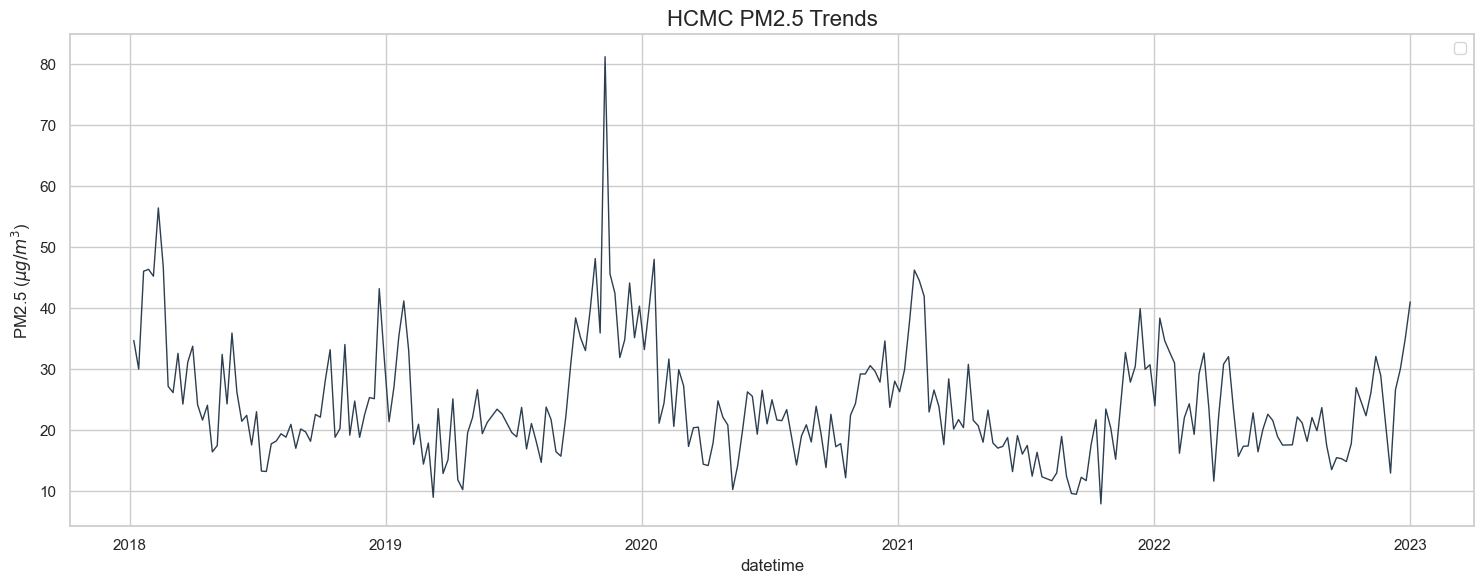

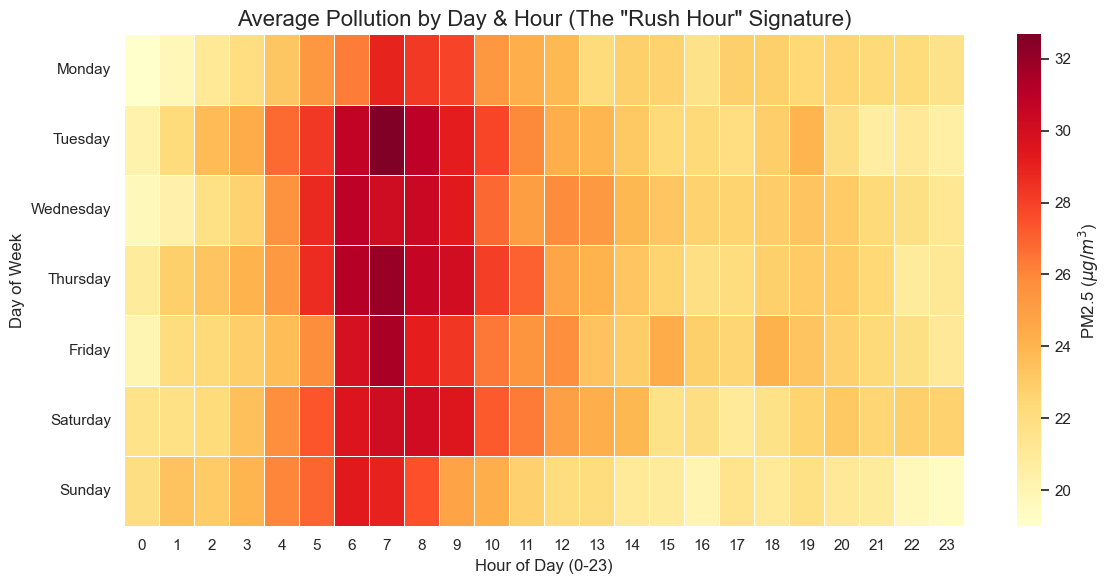

C:\Users\Eroz\AppData\Local\Temp\ipykernel_20472\3583645673.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month', y='value', palette="coolwarm", showfliers=False)


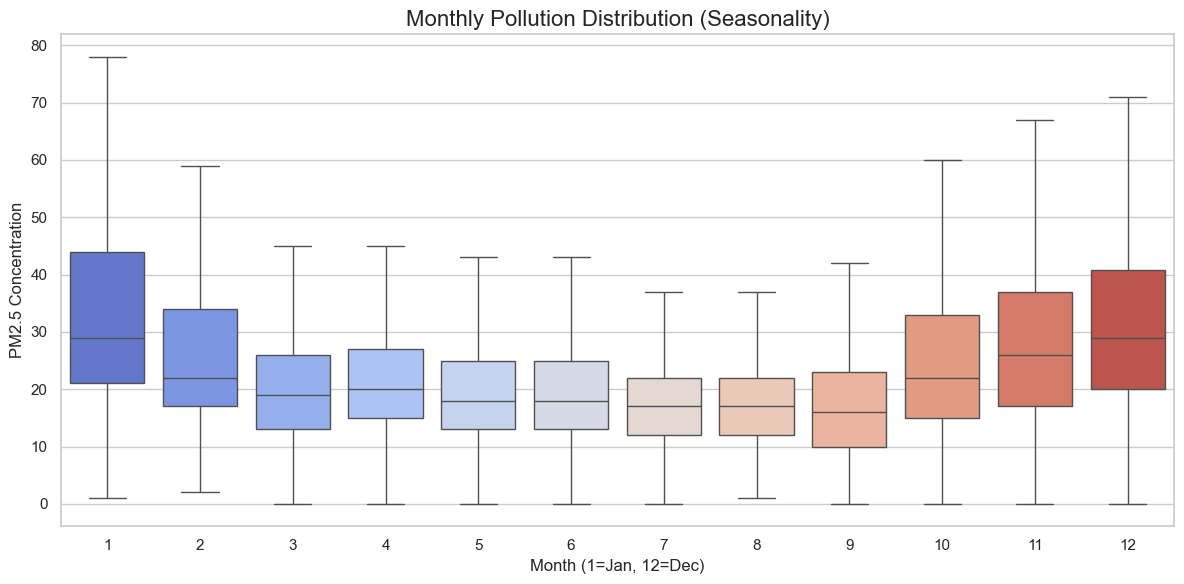

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

input_file = "hcmc_cleaned_data.csv"  

def plot(input_file):

    df = pd.read_csv(input_file)
    df['datetime'] = pd.to_datetime(df['datetime'])

    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['hour'] = df['datetime'].dt.hour
    df['day_name'] = df['datetime'].dt.day_name()

    # Set the visual style
    sns.set_theme(style="whitegrid")

    # --- PLOT 1: THE 5-YEAR TIMELINE (The Big Picture) ---
    plt.figure(figsize=(15, 6))
    # Resample to Daily or Week or Month to make the plot readable (too much noise in hourly)
    daily_df = df.set_index('datetime').resample('W')['value'].mean().reset_index()

    sns.lineplot(data=daily_df, x='datetime', y='value', color='#2c3e50', linewidth=1)


    plt.title('HCMC PM2.5 Trends', fontsize=16)
    plt.ylabel('PM2.5 ($μg/m^3$)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- PLOT 2: "RUSH HOUR" HEATMAP---
    # We pivot the data: Rows = Day of Week, Columns = Hour of Day
    pivot_table = df.pivot_table(index='day_name', columns='hour', values='value', aggfunc='mean')

    # Reorder days to start on Monday
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    pivot_table = pivot_table.reindex(days_order)

    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot_table, cmap="YlOrRd", linewidths=0.5, cbar_kws={'label': 'PM2.5 ($μg/m^3$)'})
    plt.title('Average Pollution by Day & Hour (The "Rush Hour" Signature)', fontsize=16)
    plt.xlabel('Hour of Day (0-23)')
    plt.ylabel('Day of Week')
    plt.tight_layout()
    plt.show()

    # --- PLOT 3: SEASONAL BOXPLOT (Rainy vs Dry Season) ---
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='month', y='value', palette="coolwarm", showfliers=False)
    plt.title('Monthly Pollution Distribution (Seasonality)', fontsize=16)
    plt.xlabel('Month (1=Jan, 12=Dec)')
    plt.ylabel('PM2.5 Concentration')
    plt.tight_layout()
    plt.show()

plot(input_file)


# CMT8 Sensor

In [7]:
input_file = "hcmc_cmt8_pm25_2024-11-19_to_2026-01-18.csv"
output_file = "hcmc_cmt8_cleaned_data.csv"
clean_data(input_file, output_file)

   > Total Missing Hours (Gaps): 1317


C:\Users\Eroz\AppData\Local\Temp\ipykernel_20472\3583645673.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


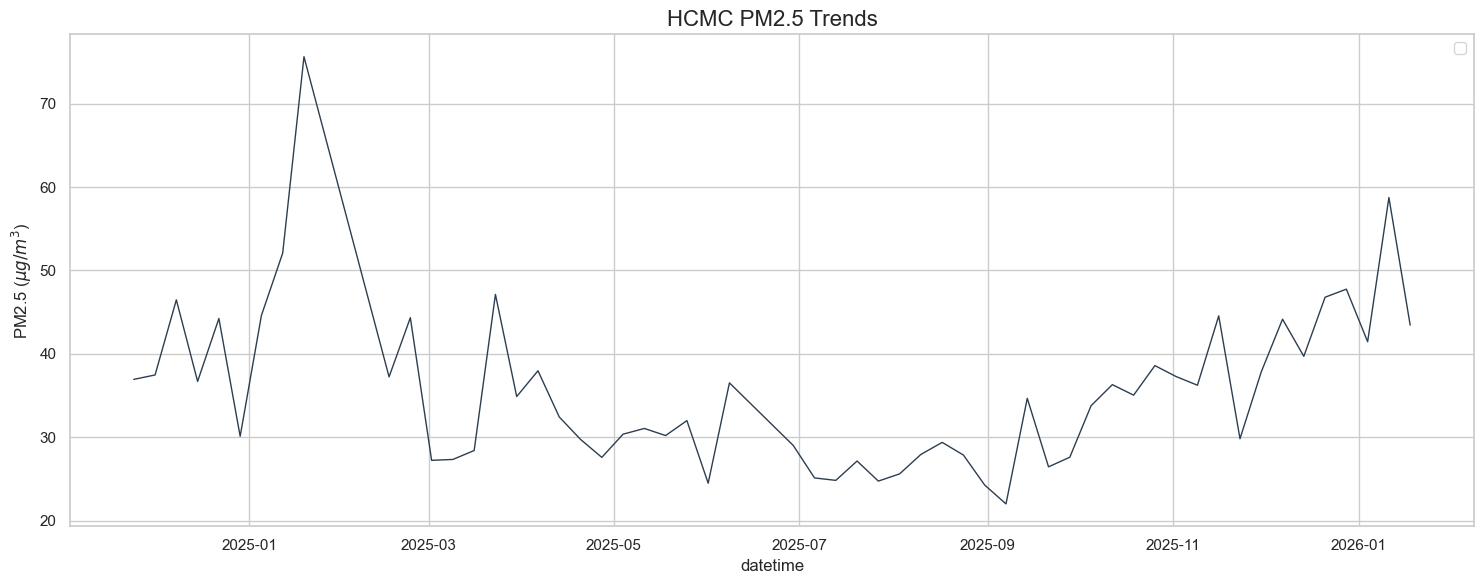

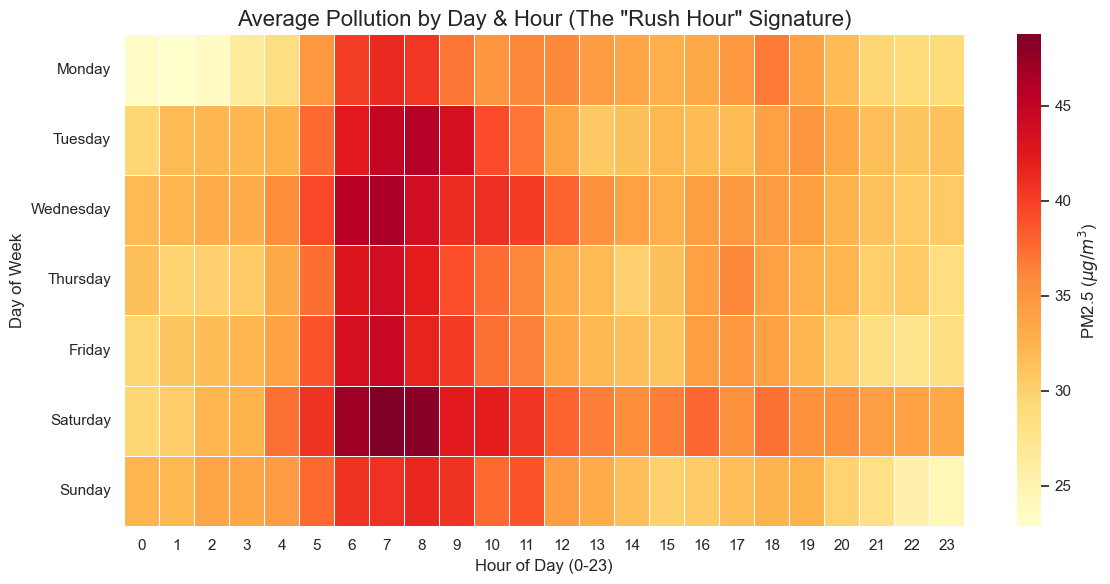

C:\Users\Eroz\AppData\Local\Temp\ipykernel_20472\3583645673.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month', y='value', palette="coolwarm", showfliers=False)


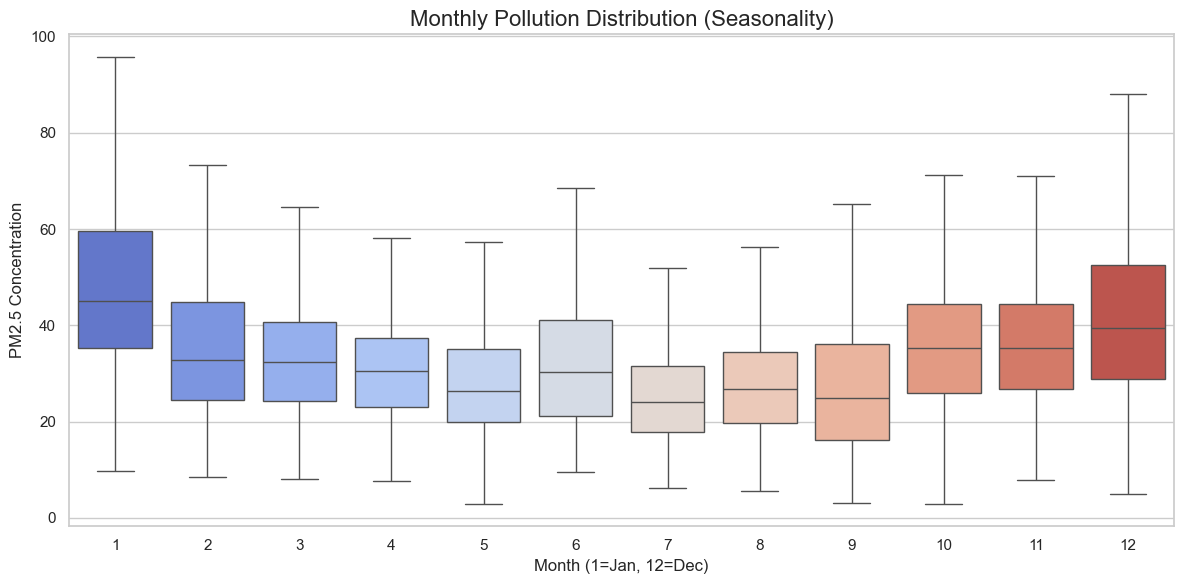

In [8]:
input_file = "hcmc_cmt8_cleaned_data.csv"
plot(input_file)

# Feature Engineering

In [9]:
import pandas as pd
import numpy as np

input_file = "hcmc_cleaned_data.csv"
output_file = "hcmc_lstm_ready.csv"

def create_features(input_file, output_file):
    #LOAD DATA
    df = pd.read_csv(input_file)
    df['dt'] = pd.to_datetime(df['datetime'])
    df = df.set_index('dt').sort_index()
    
    #CREATE LAG FEATURES
    df['lag_1h'] = df['value'].shift(1)
    df['lag_2h'] = df['value'].shift(2)
    df['lag_3h'] = df['value'].shift(3)

    # Daily Seasonality (24 hours ago)
    # "What was the pollution at this exact time yesterday?"
    df['lag_24h'] = df['value'].shift(24)
    
    # Weekly Seasonality (168 hours ago)
    # "What was the pollution at this time last week?" (Crucial for predicting Sundays)
    df['lag_168h'] = df['value'].shift(168)

    # 3. ROLLING WINDOWS (The "Trend")
    # Captures the general "mood" of the air (getting worse or getting better?)
    df['roll_mean_24h'] = df['value'].rolling(window=24).mean()
    df['roll_std_24h']  = df['value'].rolling(window=24).std()
    
    # 4. CYCLICAL TIME FEATURES (The "Clock")
    # We transform linear time (0-23) into a circle (Sin/Cos)
    # This prevents the AI from thinking 23 is "far away" from 0.
    print("Generating Cyclical Time Features...")
    
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek # 0=Monday, 6=Sunday
    df['month'] = df.index.month
    
    # Hour of Day (Period 24)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    # Month of Year (Period 12) - Captures Rainy vs Dry season
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # Day of Week (Period 7) - Helps distinguish Weekend vs Weekday
    df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    # 5. CLEANUP
    # The 'shift(168)' creates 168 rows of NaN at the start (because they have no past).
    # We must drop them.
    original_len = len(df)
    df_final = df.dropna()
    print(f"Dropped {original_len - len(df_final)} rows due to Lag creation (first week of data).")
    
    # Select final columns in a nice order
    features = [
        'datetime', 'value',             # Target & ID
        'lag_1h', 'lag_2h', 'lag_3h',    # Short term
        'lag_24h', 'lag_168h',           # Seasonal
        'roll_mean_24h', 'roll_std_24h', # Trends
        'hour_sin', 'hour_cos',          # Time
        'day_sin', 'day_cos',
        'month_sin', 'month_cos'
    ]
    
    # Reset index to keep datetime as a column
    df_final = df_final.reset_index()[features]
    
    # 6. SAVE
    df_final.to_csv(output_file, index=False)
    print(f"\nDataset saved to {output_file}")
    print(f"   > Final Training Rows: {len(df_final)}")
    print(f"   > Total Features: {len(features) - 2} (excluding datetime/value)")

create_features(input_file, output_file)

Generating Cyclical Time Features...
Dropped 15720 rows due to Lag creation (first week of data).

Dataset saved to hcmc_lstm_ready.csv
   > Final Training Rows: 22113
   > Total Features: 13 (excluding datetime/value)
